In [1]:
import pandas as pd
ames = pd.read_csv('AmesHousing.csv')
ames.head()

,Lot Area,Overall Qual,Overall Cond,Gr Liv Area,TotRms AbvGrd,Yr Sold,SalePrice
0,31770,6,5,1656,7,2010,215000
1,11622,5,6,896,5,2010,105000
2,14267,6,6,1329,6,2010,172000
3,11160,7,5,2110,8,2010,244000
4,13830,5,5,1629,6,2010,189900


#### Choosing the number of clusters

In [2]:
# For n = 1, ..., 15 clusters, print the inertia of the cluster model

from sklearn.cluster import KMeans

for n in range(1,16):
    model = KMeans(n_clusters = n).fit(ames)
    print(model.inertia_)

18875160923941.52
7264760991758.482
4027711967945.099
2605060501853.0356
1945036633108.0022
1388643026332.5903
1051467600760.0414
984155634789.2444
743056570874.1704
628743673396.8876
586544913899.5642
512514958500.6102
463064069572.5007
407407591836.17773
329868194842.8256


In [3]:
import matplotlib.pyplot as plt

In [4]:
x_variable = range(1,16)

In [5]:
y_variable = [ ]

for n in range(1,16):

    model = KMeans(n_clusters = n).fit(ames)

    y_variable.append(model.inertia_)

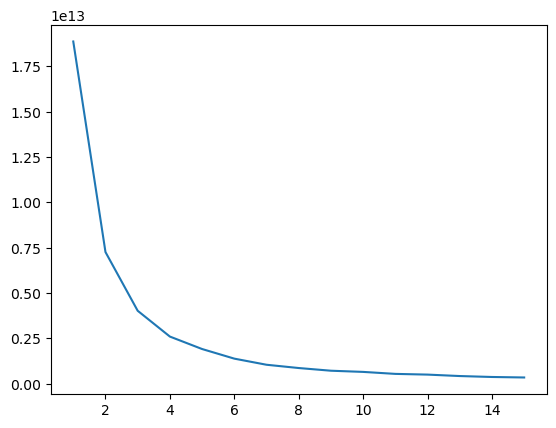

In [6]:
plt.plot(x_variable, y_variable)

##### Building cluster models for 3 & 4

In [7]:
# Cluster the data in 3 and 4 clusters

model_3 = KMeans(
    n_clusters=3,
    random_state=13
).fit(ames)

model_4 = KMeans(
    n_clusters=4,
    random_state=13
).fit(ames)

In [8]:
# Add labels to the ames data

ames['3-cluster'] = model_3.labels_
ames['4-cluster'] = model_4.labels_

ames.head()

,Lot Area,Overall Qual,Overall Cond,Gr Liv Area,TotRms AbvGrd,Yr Sold,SalePrice,3-cluster,4-cluster
0,31770,6,5,1656,7,2010,215000,2,2
1,11622,5,6,896,5,2010,105000,0,0
2,14267,6,6,1329,6,2010,172000,0,2
3,11160,7,5,2110,8,2010,244000,2,1
4,13830,5,5,1629,6,2010,189900,2,2


In [9]:
ames.groupby('3-cluster').count()

,Lot Area,Overall Qual,Overall Cond,Gr Liv Area,TotRms AbvGrd,Yr Sold,SalePrice,4-cluster
3-cluster,,,,,,,,
0,1686,1686,1686,1686,1686,1686,1686,1686
1,243,243,243,243,243,243,243,243
2,1001,1001,1001,1001,1001,1001,1001,1001


In [10]:
ames.groupby('4-cluster').count()

,Lot Area,Overall Qual,Overall Cond,Gr Liv Area,TotRms AbvGrd,Yr Sold,SalePrice,3-cluster
4-cluster,,,,,,,,
0,1298,1298,1298,1298,1298,1298,1298,1298
1,476,476,476,476,476,476,476,476
2,1032,1032,1032,1032,1032,1032,1032,1032
3,124,124,124,124,124,124,124,124


In [11]:
ames.groupby(['3-cluster','4-cluster']).count()

Lot Area  Overall Qual  Overall Cond  Gr Liv Area  \
3-cluster 4-cluster                                                      
0         0              1298          1298          1298         1298   
          2               388           388           388          388   
1         1               119           119           119          119   
          3               124           124           124          124   
2         1               357           357           357          357   
          2               644           644           644          644   

                     TotRms AbvGrd  Yr Sold  SalePrice  
3-cluster 4-cluster                                     
0         0                   1298     1298       1298  
          2                    388      388        388  
1         1                    119      119        119  
          3                    124      124        124  
2         1                    357      357        357  
          2                    644      644        644

We will stick with the 4 cluster model.

##### Analysing the clusters

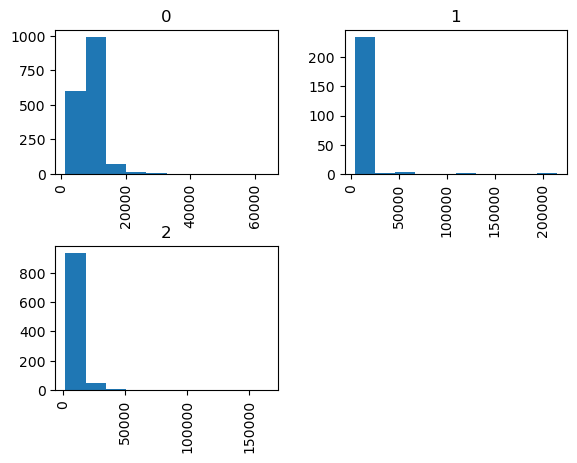

In [21]:
ames['Lot Area'].hist(by = ames['3-cluster']);

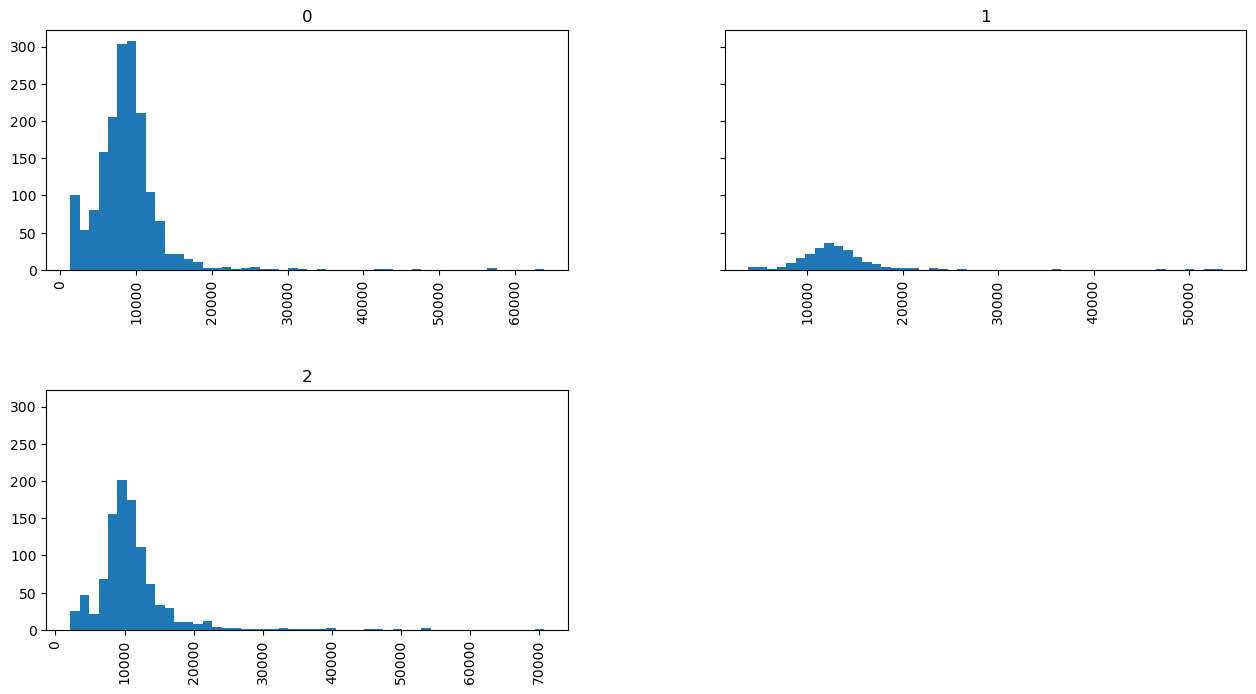

In [35]:
ames[ames['Lot Area']<100000]['Lot Area'].hist( # The figures should only have data up to 100,000
    by = ames['3-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

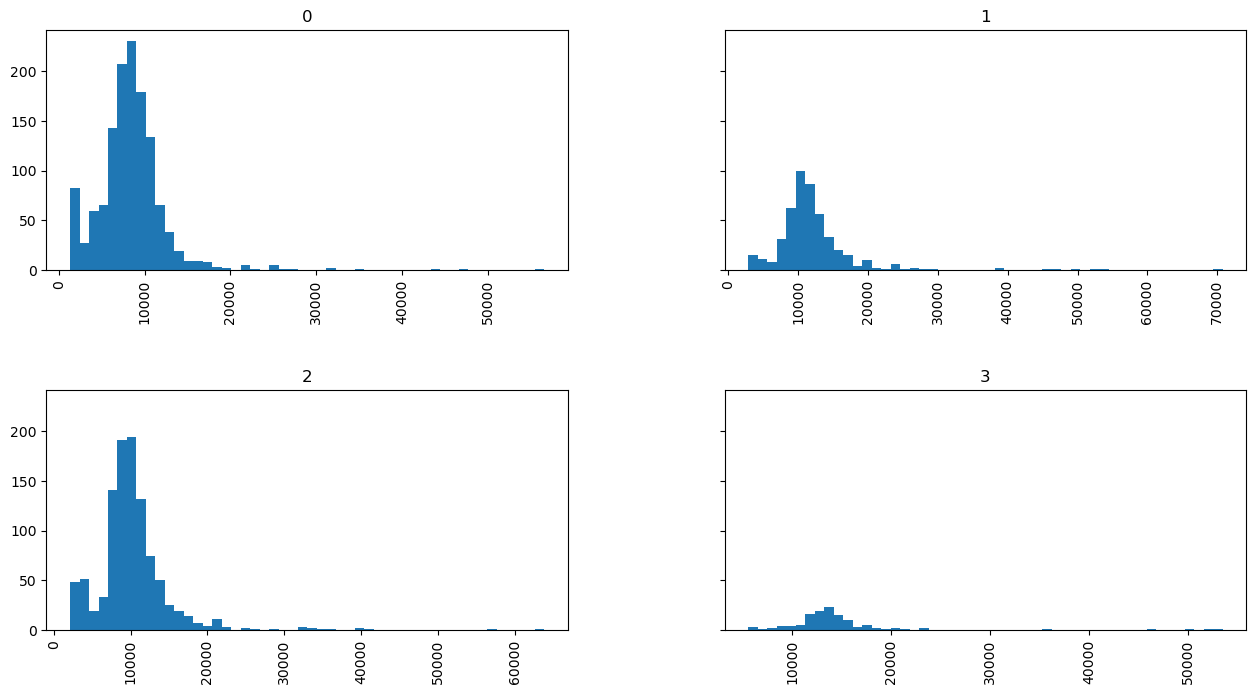

In [36]:
ames[ames['Lot Area']<100000]['Lot Area'].hist( # The figures should only have data up to 100,000
    by = ames['4-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

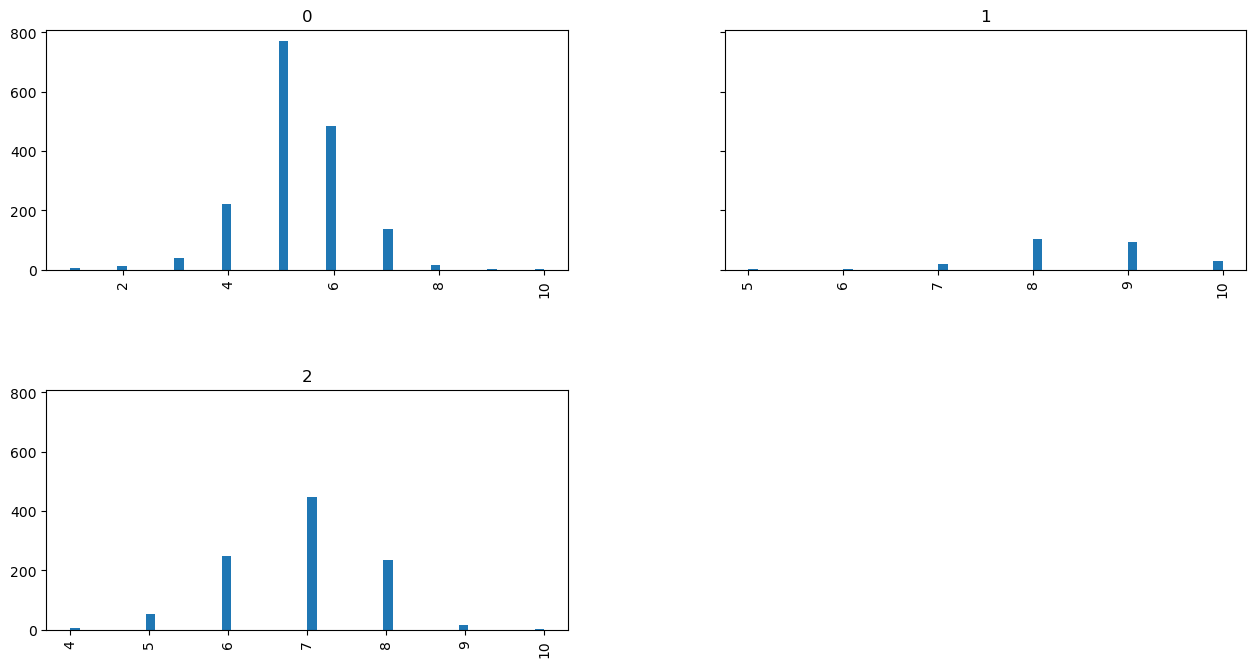

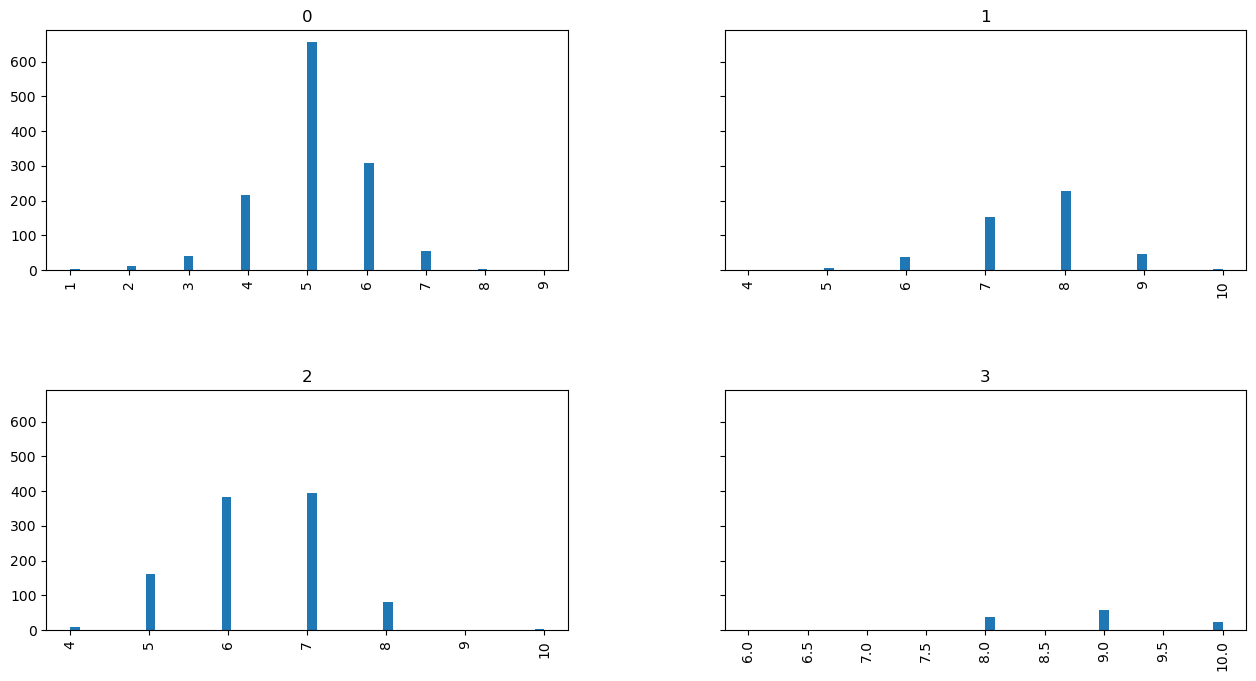

In [38]:
ames['Overall Qual'].hist( 
    by = ames['3-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
)
ames['Overall Qual'].hist(
    by = ames['4-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

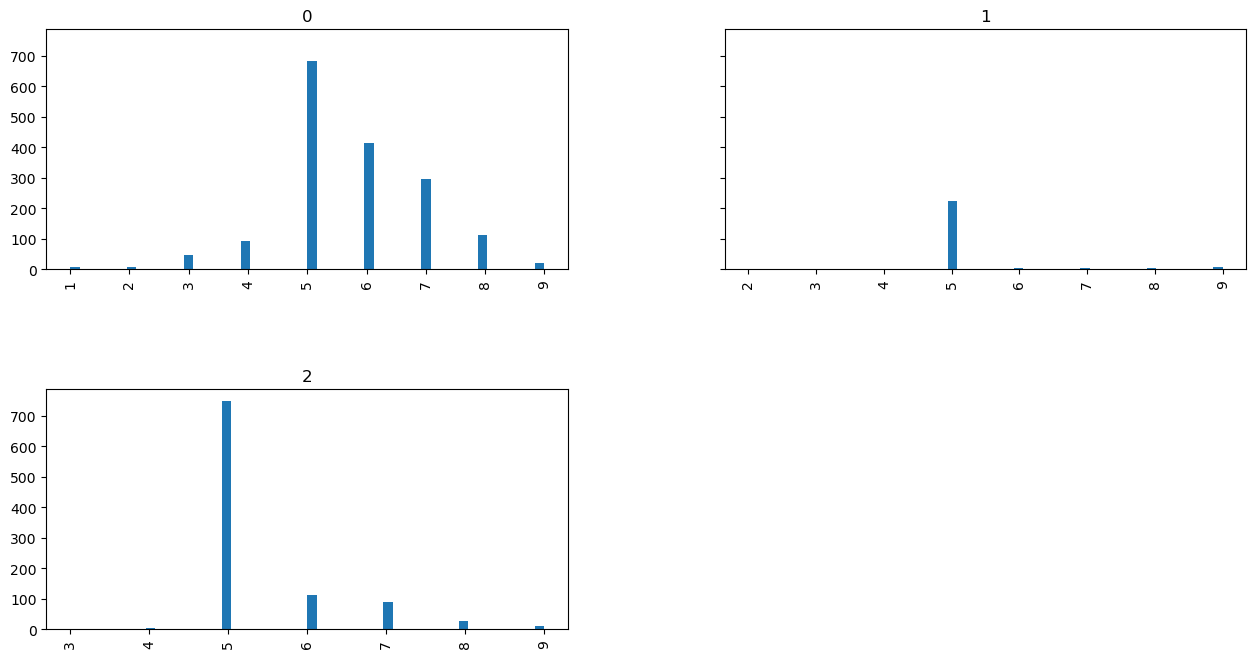

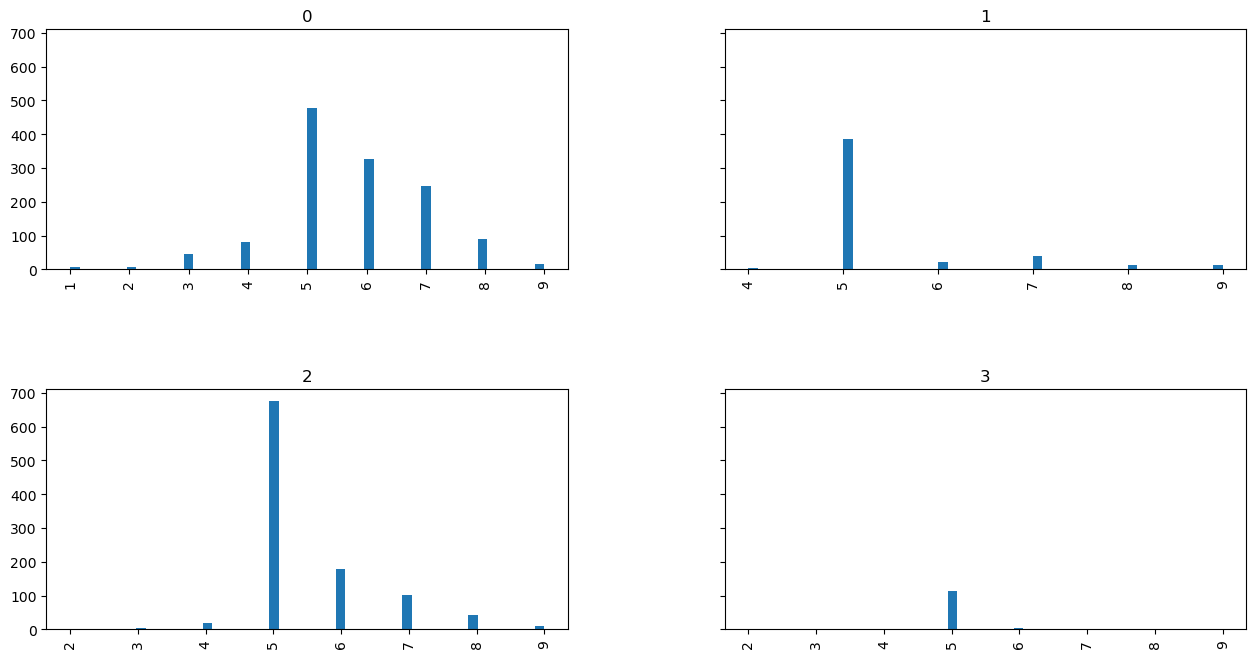

In [39]:
ames['Overall Cond'].hist( 
    by = ames['3-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
)
ames['Overall Cond'].hist( 
    by = ames['4-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

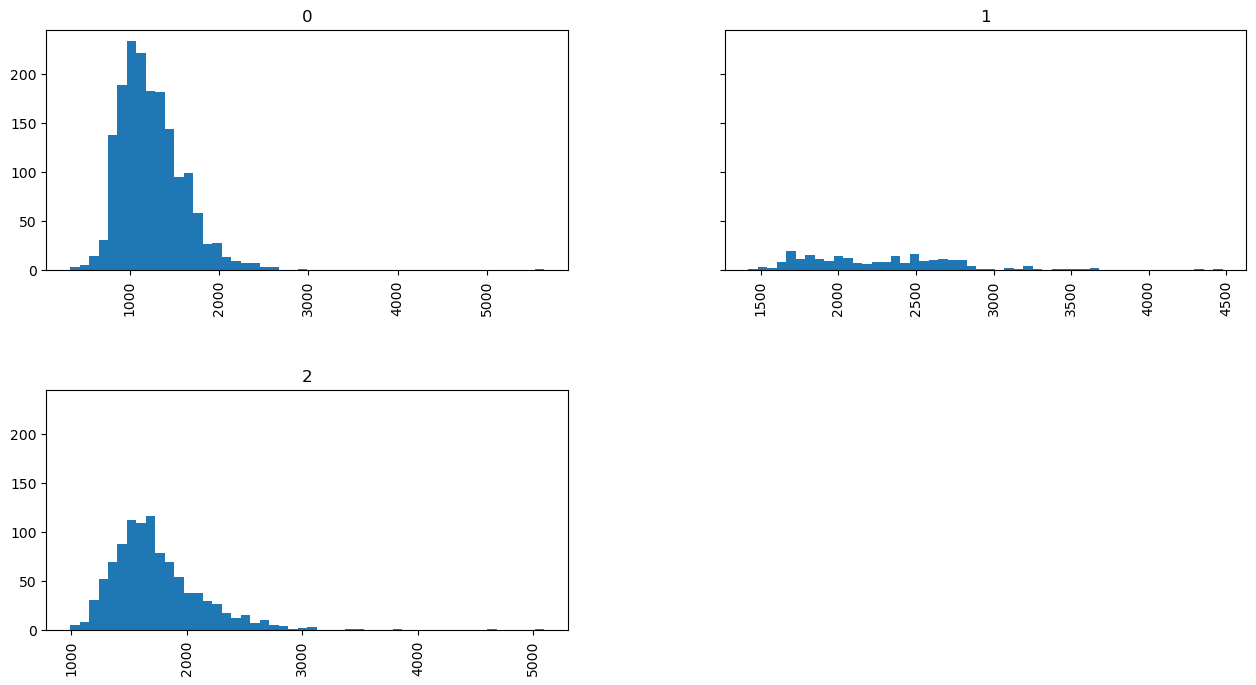

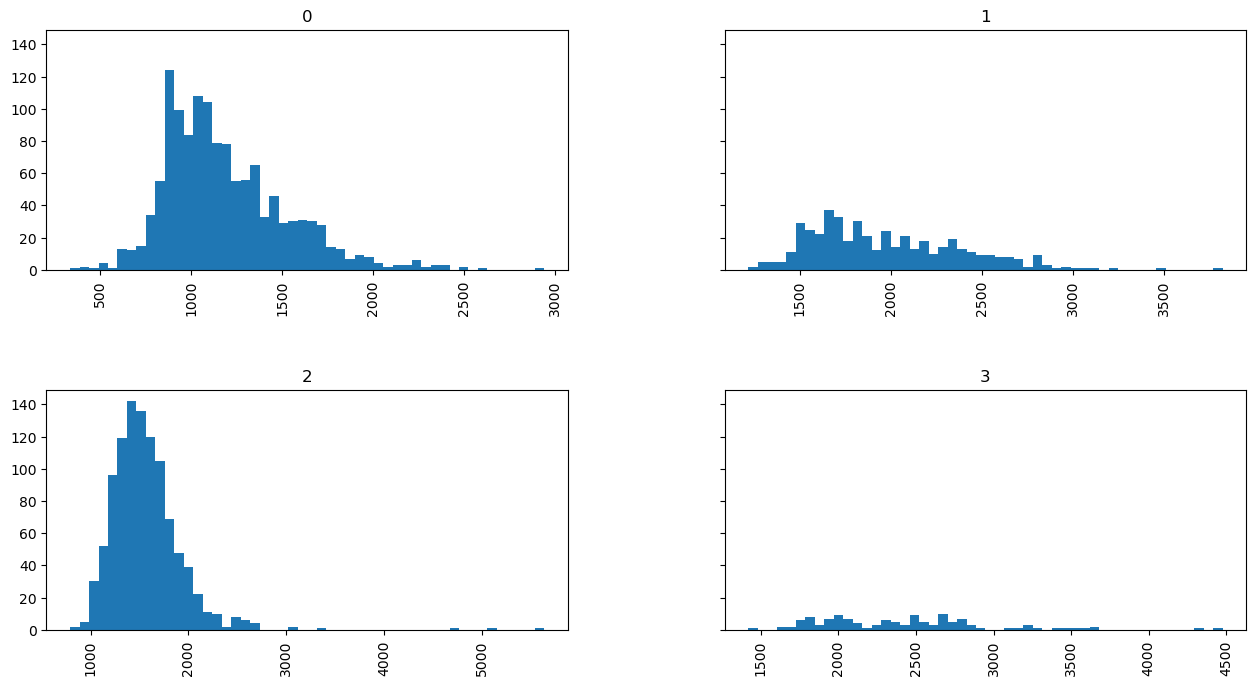

In [40]:
ames['Gr Liv Area'].hist( 
    by = ames['3-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
)
ames['Gr Liv Area'].hist(
    by = ames['4-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

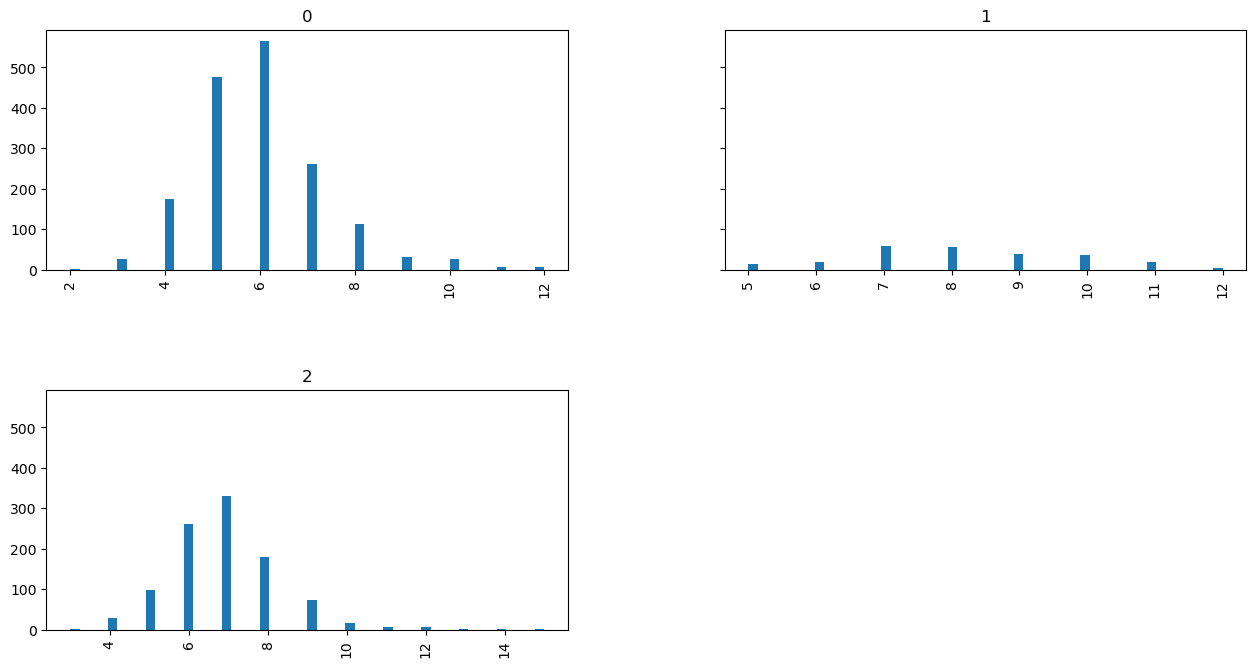

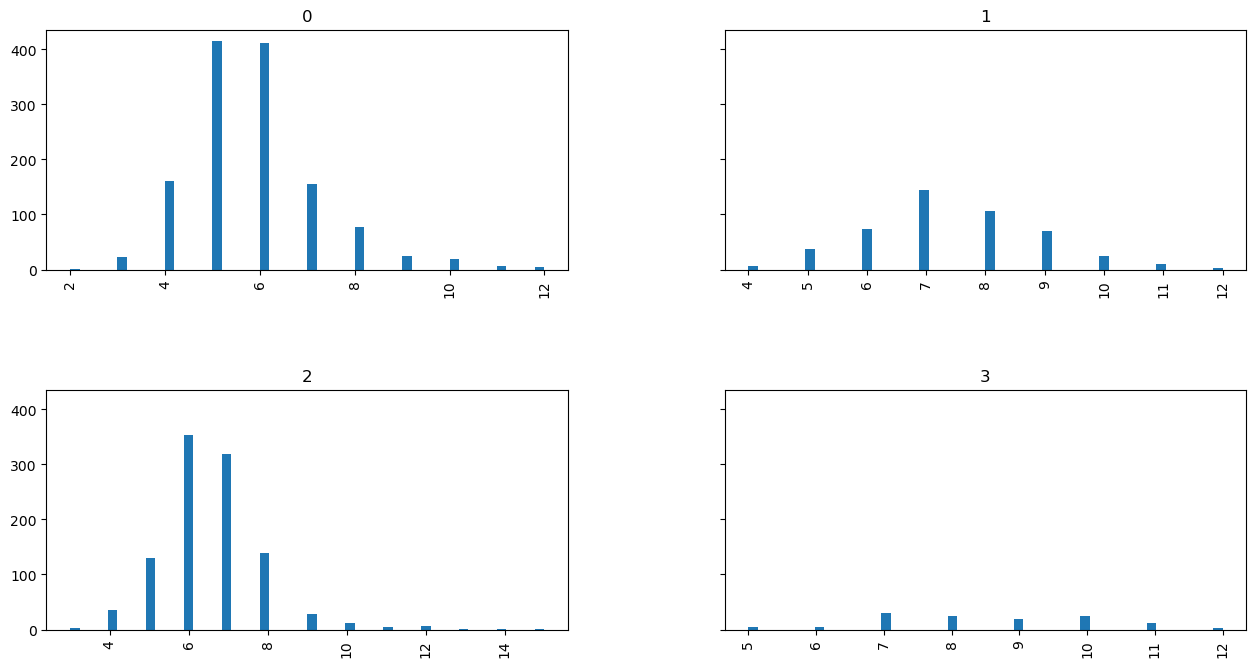

In [41]:
ames['TotRms AbvGrd'].hist( 
    by = ames['3-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
)
ames['TotRms AbvGrd'].hist( 
    by = ames['4-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

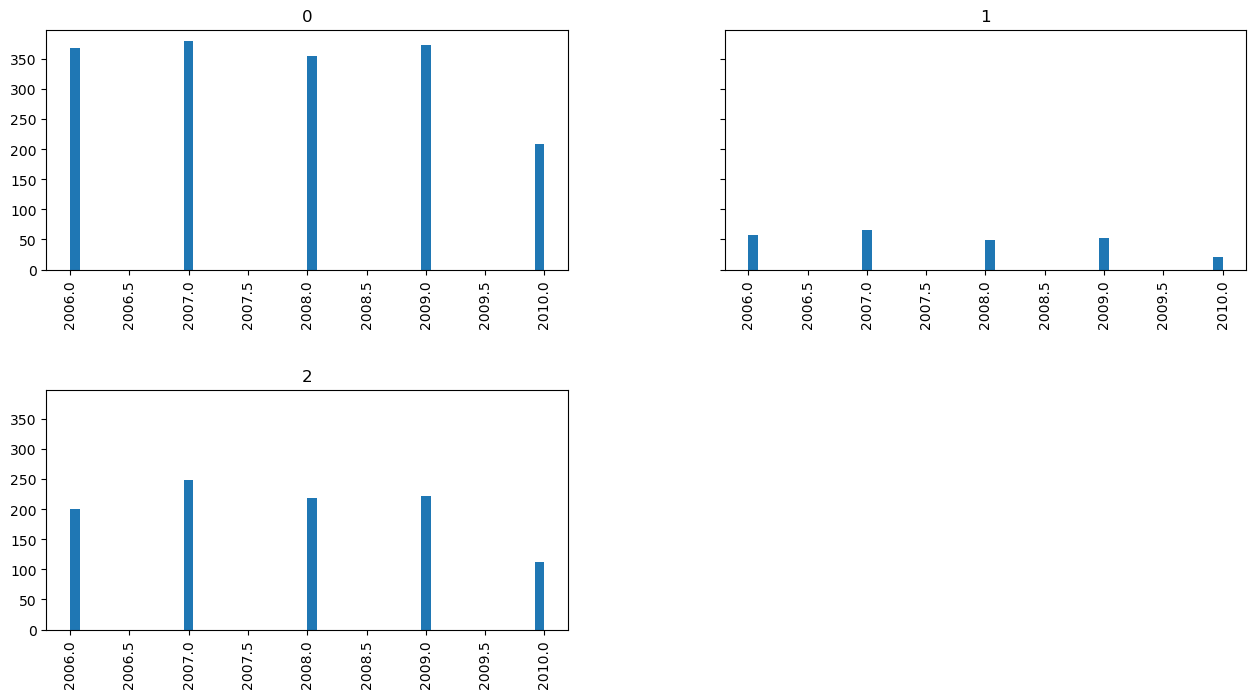

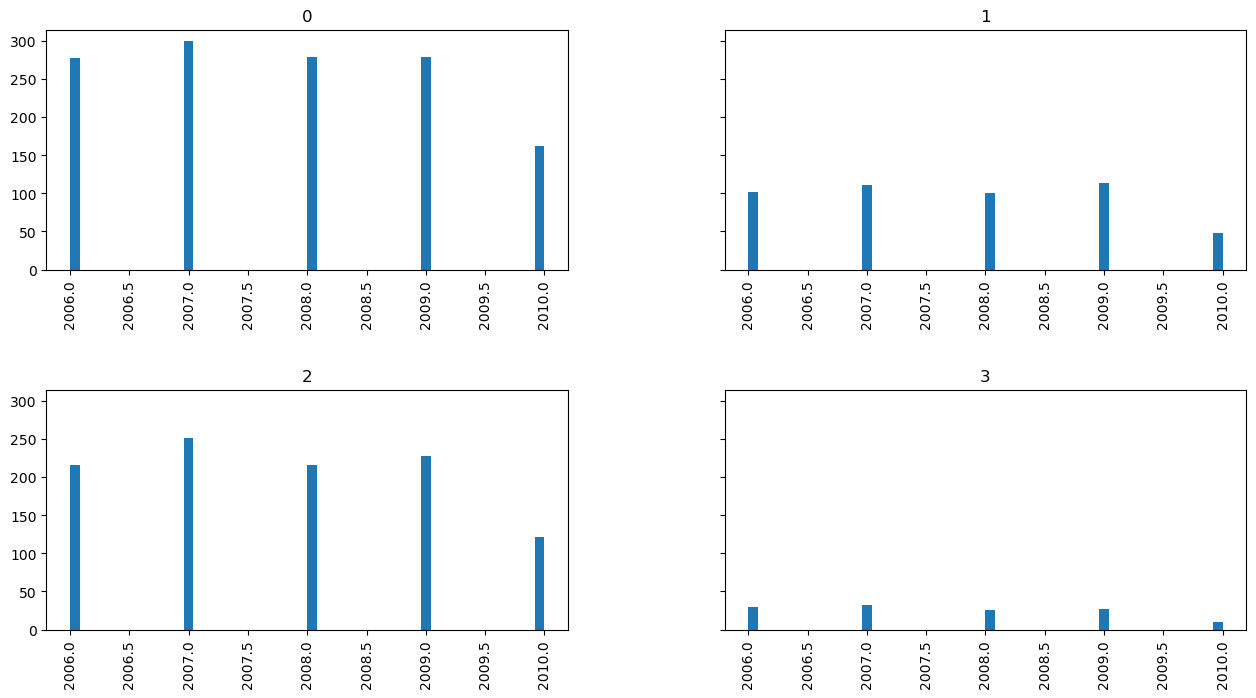

In [42]:
ames['Yr Sold'].hist( 
    by = ames['3-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
)
ames['Yr Sold'].hist( 
    by = ames['4-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);

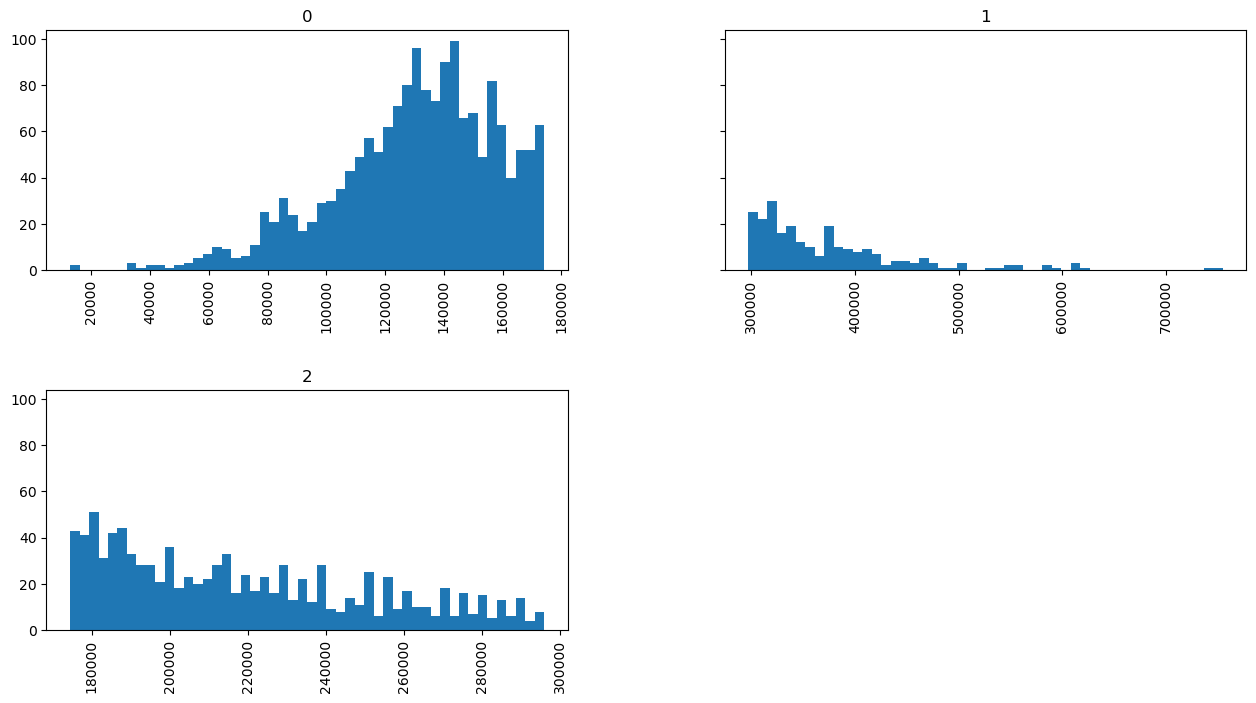

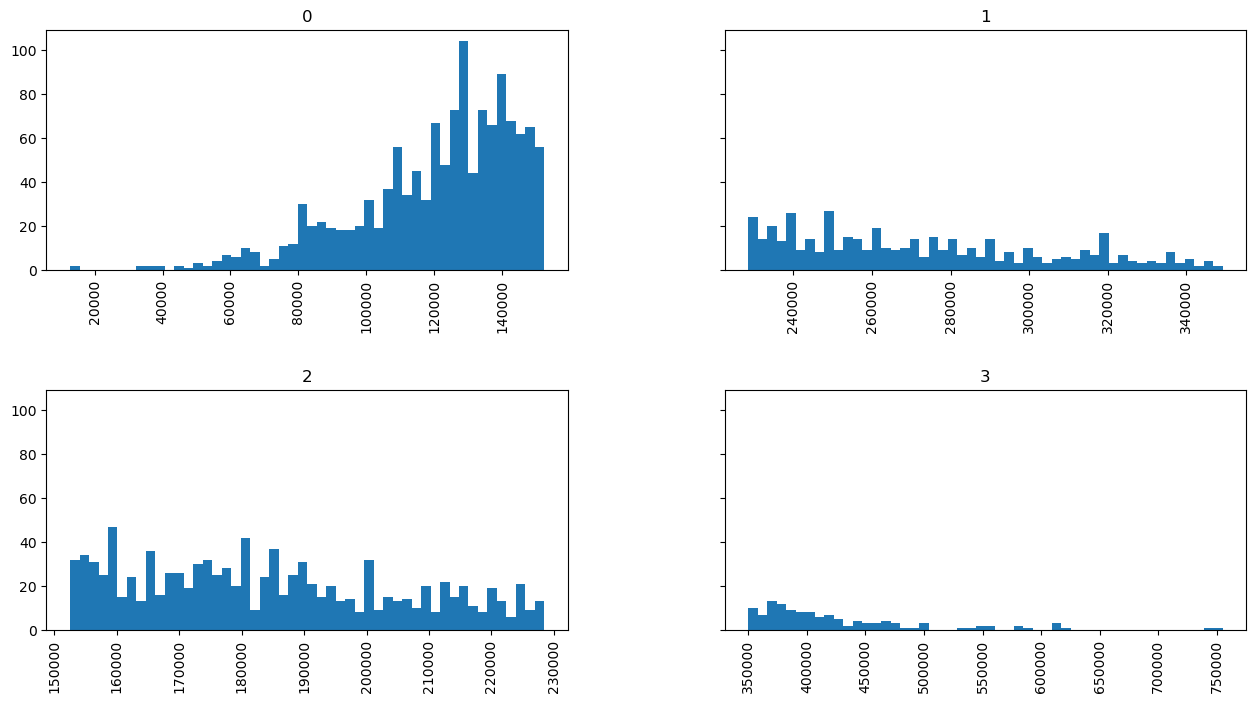

In [43]:
ames['SalePrice'].hist( 
    by = ames['3-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
)
ames['SalePrice'].hist( 
    by = ames['4-cluster'],
    sharey = True, # The figures should have the same y axis
    bins = 50, # The figures should have 50 bins
    figsize = (15,8) # The figures should be bigger
);